In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Feature-Engineered Dataset
data_path = os.path.join('data', 'all_months_features.csv')

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"✓ Feature-engineered dataset loaded successfully. Shape: {df.shape}")
else:
    raise FileNotFoundError(f"File not found at '{data_path}'. Run step 04 first.")

✓ Feature-engineered dataset loaded successfully. Shape: (798, 77)


In [21]:
#  Define target columns
target_cols = ['Avg_Price', 'Min_Price', 'Max_Price']

# Filter out rows where target prices are missing
df_model = df.dropna(subset=target_cols).copy()

# Sort and reset index to avoid IndexingError / Unalignable boolean Series
df_model = df_model.sort_values(by=['Product_Name']).reset_index(drop=True)

# Re-assign sequential month index (1 to 10) per product
df_model['month_idx'] = df_model.groupby('Product_Name').cumcount() + 1

# Identify feature columns (exclude targets & non-predictive metadata)
ignore_cols = target_cols + ['Product_Name', 'Category', 'Unit', 'unit_canonical', 'month_name', 'bs_year', 'bs_month']
feature_cols = [c for c in df_model.columns if c not in ignore_cols]

# Build Feature Matrix (X) and Target Matrix (y) with matching aligned index
X = df_model[feature_cols].fillna(0)
y = df_model[target_cols]

print(f" Targets ({len(target_cols)}): {target_cols}")
print(f" Predictive Features ({len(feature_cols)}): {feature_cols}")
print(f" Total rows ready for modeling: {len(df_model)}")

 Targets (3): ['Avg_Price', 'Min_Price', 'Max_Price']
 Predictive Features (67): ['month_idx', 'Volume', 'unit_changed', 'Total_Amount', 'Volume_Equals', 'TOTAL_sources', 'reconciliation_gap', 'import_share', 'n_months_present', 'is_balanced', 'Baglung', 'Bara', 'Beni', 'Bhutan', 'Birgunj', 'China', 'Dang', 'Dhading', 'Gorkha', 'Hetauda', 'India', 'Jhapa', 'Kathmandu', 'Kevray', 'Lahan', 'Lamjung', 'Local', 'Marpha', 'Mugu', 'Mustang', 'Myagdi', 'Narayangadh', 'Nawalparasi', 'Nuwakot', 'Palpa', 'Parbat', 'Rolpa', 'Rukum', 'Rupandehi', 'Salyan', 'Sarlahi', 'Sindhuli', 'Sunsari', 'Syangja', 'Tanahu', 'Avg_Price_lag1', 'Avg_Price_lag2', 'Avg_Price_roll3_mean', 'Avg_Price_roll3_std', 'Min_Price_lag1', 'Min_Price_lag2', 'Min_Price_roll3_mean', 'Min_Price_roll3_std', 'Max_Price_lag1', 'Max_Price_lag2', 'Max_Price_roll3_mean', 'Max_Price_roll3_std', 'price_spread', 'price_spread_ratio', 'Volume_lag1', 'TOTAL_sources_lag1', 'volume_change_ratio', 'sin_month', 'cos_month', 'total_imports', 'imp

In [ ]:
# Chronological Time-Based Train/Test Split
# Months 1 to 8: Training | Months 9 to 10: Validation/Testing
train_mask = df_model['month_idx'] <= 8
test_mask = df_model['month_idx'] > 8

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f" Train Set (Months 1–8): {X_train.shape[0]} rows")
print(f" Test Set (Months 9–10): {X_test.shape[0]} rows")

 Train Set (Months 1–8): 624 rows
 Test Set (Months 9–10): 97 rows


In [ ]:
# Model Ingestion & Multi-Target Training
# Initialize Base Estimator and MultiOutput Regressor
base_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model = MultiOutputRegressor(base_model)

print("\n Training Multi-Output Regression Model...")
model.fit(X_train, y_train)
print("✓ Model Training Complete.")


 Training Multi-Output Regression Model...
✓ Model Training Complete.


In [24]:
# Model Predictions & Multi-Target Evaluation
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_df = pd.DataFrame(y_pred, columns=target_cols, index=y_test.index)

print("\n=== MULTI-TARGET MODEL EVALUATION RESULTS ===")
metrics_list = []

for col in target_cols:
    mae = mean_absolute_error(y_test[col], y_pred_df[col])
    rmse = np.sqrt(mean_squared_error(y_test[col], y_pred_df[col]))
    r2 = r2_score(y_test[col], y_pred_df[col])
    
    metrics_list.append({
        'Target': col,
        'MAE (NPR)': round(mae, 2),
        'RMSE (NPR)': round(rmse, 2),
        'R2 Score': round(r2, 4)
    })

eval_summary = pd.DataFrame(metrics_list)
display(eval_summary)


=== MULTI-TARGET MODEL EVALUATION RESULTS ===


,Target,MAE (NPR),RMSE (NPR),R2 Score
0,Avg_Price,32.76,65.03,0.8799
1,Min_Price,22.54,36.71,0.7869
2,Max_Price,29.08,75.25,0.7982


/var/folders/7g/ncvyfv3n01gds4p5h1m65g0w0000gn/T/ipykernel_6431/2003610118.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


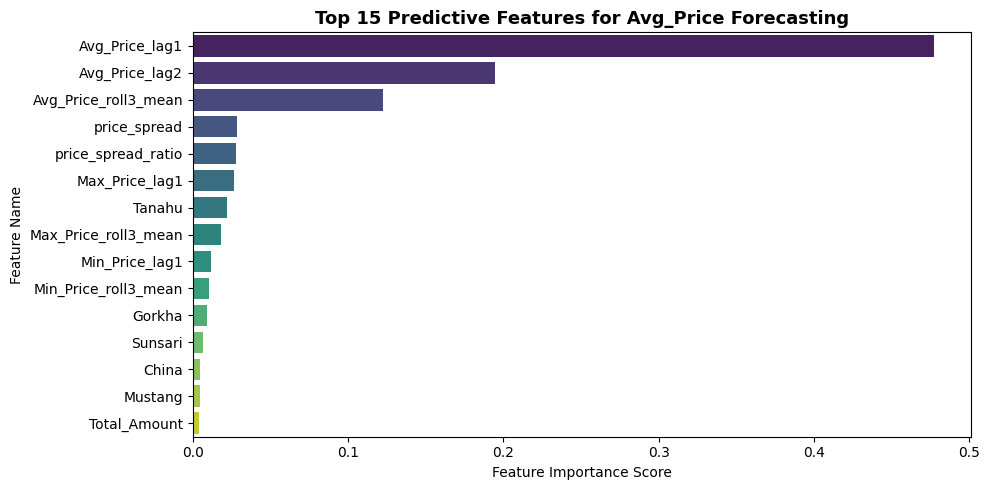

In [25]:
# Feature importance inception
# Extract feature importances from the first estimator (Avg_Price)
importances = model.estimators_[0].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 15 Predictive Features for Avg_Price Forecasting', fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [26]:
# Export Model Predictions
# Format and Export Forecast Results
results_df = df_model.loc[y_test.index, ['Product_Name', 'month_idx']].copy()

for col in target_cols:
    results_df[f'Actual_{col}'] = y_test[col]
    results_df[f'Predicted_{col}'] = y_pred_df[col]

output_path = os.path.join('data', 'forecast_results.csv')
results_df.to_csv(output_path, index=False)

print(f"\n✓ Forecast results saved to '{output_path}'")


✓ Forecast results saved to 'data/forecast_results.csv'


In [27]:
# Predict across ALL 10 months (X)
y_pred_all = model.predict(X)
y_pred_all_df = pd.DataFrame(y_pred_all, columns=target_cols, index=X.index)

# Build results dataframe for all months
results_all_df = df_model[['Product_Name', 'month_idx']].copy()

for col in target_cols:
    results_all_df[f'Actual_{col}'] = y[col]
    results_all_df[f'Predicted_{col}'] = y_pred_all_df[col]

# Save all months results
output_path = os.path.join('data', 'forecast_results_all_months.csv')
results_all_df.to_csv(output_path, index=False)

print(f"✓ Complete 10-month forecast results saved to '{output_path}'")

✓ Complete 10-month forecast results saved to 'data/forecast_results_all_months.csv'
